In [1]:
import io
import string

import beaker
import faceted
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import wandb
import xarray as xr

from typing import Literal

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import plotting
import utils

In [2]:
REFERENCE = {
    "SHiELD": utils.beaker_dataset_id_from_name("2026-02-21-2pctCO2-ic_0001-data-only-evaluator"),
    "SHiELD-ic_0002": utils.beaker_dataset_id_from_name("2026-02-21-2pctCO2-ic_0002-data-only-evaluator"),
}
INCREASING = {
    "full-energy-conserving-rs0": utils.beaker_dataset_id_from_name("2026-09-09-full-energy-conserving-rs0-extended-2pctCO2-inference"),
    "full-energy-conserving-rs1": utils.beaker_dataset_id_from_name("2026-09-09-full-energy-conserving-rs1-extended-2pctCO2-inference")
}
INCREASING_SECOND_MEMBER = {
    "full-energy-conserving-rs0": utils.beaker_dataset_id_from_name("2026-09-09-full-energy-conserving-rs0-extended-2pctCO2-inference-second-ensemble-member"),
    "full-energy-conserving-rs1": utils.beaker_dataset_id_from_name("2026-09-09-full-energy-conserving-rs1-extended-2pctCO2-inference-second-ensemble-member")
}

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Experiment'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages

In [3]:
COLORS = {
    "SHiELD": "k",
    "full-energy-conserving-rs0": "C4",
    "full-energy-conserving-rs1": "C4",
}


In [4]:
ANNUAL_DIAGNOSTICS = "main/annual_diagnostics.nc"


def open_beaker_dataset(dataset_id: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, ANNUAL_DIAGNOSTICS)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_datasets(dataset_ids):
    datasets = {}
    for case, dataset_id in dataset_ids.items():
        datasets[case] = open_beaker_dataset(dataset_id)
    index = pd.Index(datasets.keys(), name="case")
    return xr.concat(datasets.values(), dim=index)

In [5]:
reference = open_datasets(REFERENCE)
increasing = open_datasets(INCREASING)
increasing_second_member = open_datasets(INCREASING_SECOND_MEMBER)

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

Output()

Output()

In [6]:
MAIN_MODELS = ["full-energy-conserving-rs0"]
ALTERNATE_MODELS = {
    "full-energy-conserving-rs0": "full-energy-conserving-rs1"
}

In [7]:
# 293.6

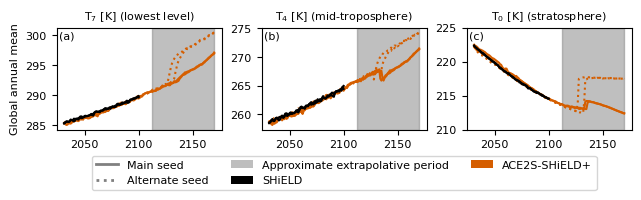

In [8]:
plotting.configure_style()

fig, (ax1, ax2, ax3) = faceted.faceted(1, 3, width=6.5, aspect=0.618, sharey=False, internal_pad=0.4, bottom_pad=0.7, left_pad=0.5)

for case in MAIN_MODELS:
    increasing.sel(case=case).air_temperature_7.plot(ax=ax1, color=COLORS[case])
    increasing.sel(case=case).air_temperature_4.plot(ax=ax2, color=COLORS[case])
    increasing.sel(case=case).air_temperature_0.plot(ax=ax3, color=COLORS[case])

    increasing_second_member.sel(case=case).air_temperature_7.plot(ax=ax1, color=COLORS[case])
    increasing_second_member.sel(case=case).air_temperature_4.plot(ax=ax2, color=COLORS[case])
    increasing_second_member.sel(case=case).air_temperature_0.plot(ax=ax3, color=COLORS[case])

    if case in ALTERNATE_MODELS:
        alternate_case = ALTERNATE_MODELS[case]
        increasing.sel(case=alternate_case).air_temperature_7.plot(ax=ax1, color=COLORS[alternate_case], ls=":")
        increasing.sel(case=alternate_case).air_temperature_4.plot(ax=ax2, color=COLORS[alternate_case], ls=":")
        increasing.sel(case=alternate_case).air_temperature_0.plot(ax=ax3, color=COLORS[alternate_case], ls=":")

        increasing_second_member.sel(case=alternate_case).air_temperature_7.plot(ax=ax1, color=COLORS[alternate_case], ls=":")
        increasing_second_member.sel(case=alternate_case).air_temperature_4.plot(ax=ax2, color=COLORS[alternate_case], ls=":")
        increasing_second_member.sel(case=alternate_case).air_temperature_0.plot(ax=ax3, color=COLORS[alternate_case], ls=":")

reference.sel(case="SHiELD").air_temperature_7.plot(ax=ax1, color=COLORS["SHiELD"])
reference.sel(case="SHiELD").air_temperature_4.plot(ax=ax2, color=COLORS["SHiELD"])
reference.sel(case="SHiELD").air_temperature_0.plot(ax=ax3, color=COLORS["SHiELD"])

reference.sel(case="SHiELD-ic_0002").air_temperature_7.plot(ax=ax1, color=COLORS["SHiELD"])
reference.sel(case="SHiELD-ic_0002").air_temperature_4.plot(ax=ax2, color=COLORS["SHiELD"])
reference.sel(case="SHiELD-ic_0002").air_temperature_0.plot(ax=ax3, color=COLORS["SHiELD"])

ax1.set_xlabel("")
ax2.set_xlabel("")
ax3.set_xlabel("")

ax1.set_ylabel("Global annual mean")
ax2.set_ylabel("")
ax3.set_ylabel("")

ax1.set_title("T$_7$ [K] (lowest level)")
ax2.set_title("T$_4$ [K] (mid-troposphere)")
ax3.set_title("T$_0$ [K] (stratosphere)")

for ax, label in zip((ax1, ax2, ax3), string.ascii_lowercase):
    ax.axvspan(2112, 2170, color="gray", alpha=0.5)

    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

legend_elements = {
    "Main seed": Line2D([0], [0], color="gray", lw=2, ls="-", label="Main seed"),
    "Alternate seed": Line2D([0], [0], color="gray", lw=2, ls=":", label="Alternate seed"),
    "Approximate extrapolative period": Patch(facecolor="gray", label="Extrapolative region", alpha=0.5, edgecolor="none"),
    "SHiELD": Patch(facecolor="k", label="SHiELD"),
    "ACE2S-SHiELD+": Patch(facecolor="C4", label="ACE2S-SHiELD+"),
}

ax2.legend(
    legend_elements.values(),
    legend_elements.keys(),
    bbox_to_anchor=(0.5, -0.2), 
    bbox_transform=ax2.transAxes, 
    loc="upper center", 
    ncol=3, 
    fontsize=8
)

ax3.set_ylim(210, 225)

fig.patch.set_alpha(0.0)
fig.savefig("figure-S13.png", dpi=300)
fig.savefig("figure-S13.pdf")